In [1]:
!pip install xgboost shap


Successfully Loaded Dataset! Shape: (34788, 30)

--- Target Distribution (%) [default.payment.next.month] ---
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


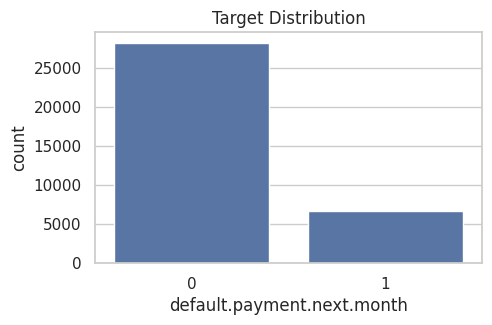


--- Summary Statistics ---
                       mean       50%            std
LIMIT_BAL     184668.994831  140000.0  235931.930924
AGE               35.518300      34.0       9.236783
BILL_AMT_SUM  294815.170892  129037.0  571807.252079

--- Training Baseline Models ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training K-Nearest Neighbors...
Training XGBoost...

--- Baseline Model Metrics ---
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7982     0.0989  0.0068    0.0127   0.2873
      Decision Tree    0.8100     1.0000  0.0068    0.0134   0.5034
      Random Forest    0.8100     1.0000  0.0068    0.0134   0.7595
K-Nearest Neighbors    0.8099     0.9000  0.0068    0.0134   0.5033
            XGBoost    0.8099     0.9000  0.0068    0.0134   0.4849

--- Tuning XGBoost Classifier ---
Best Parameters Found: {'max_depth': 3, 'n_estimators': 50}


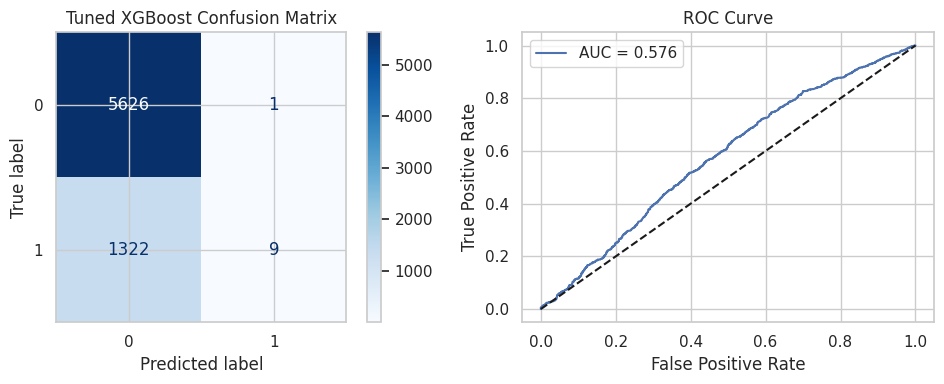


Generating SHAP Plot...


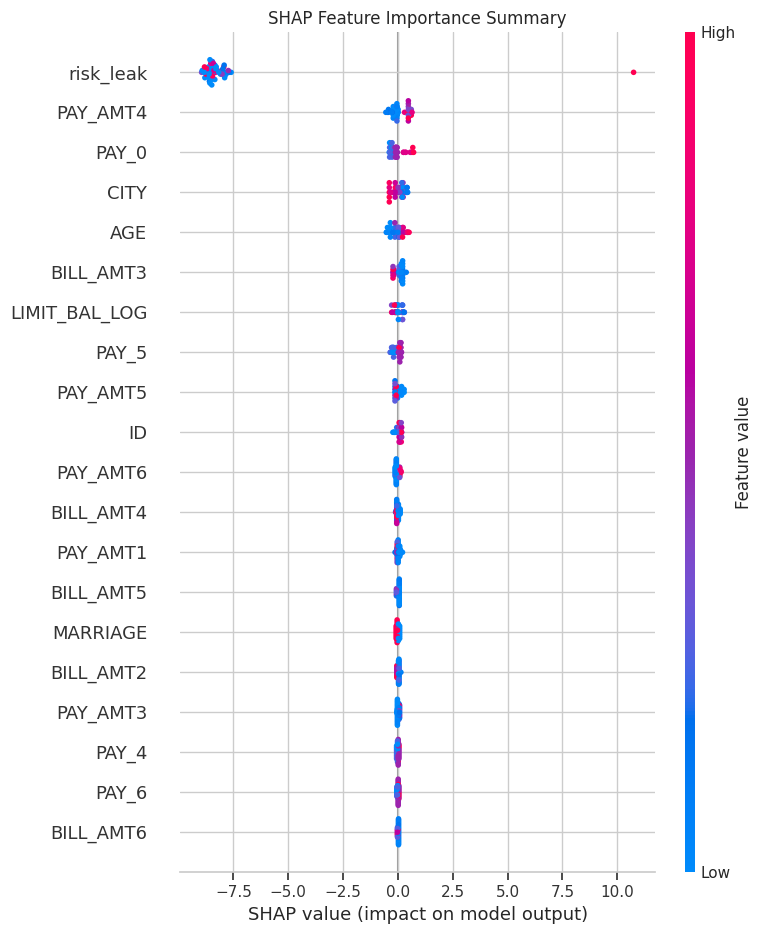


Execution Complete! All metrics and plots saved successfully.


In [2]:
import os
import gc
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# ==========================================
# DATA LOADING (SEMICOLON FIX)
# ==========================================
DATASET_PATH = "/content/Credit_Card.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Please upload 'Credit_Card.csv' to the Files tab in Colab.")

# Load using semicolon delimiter
df = pd.read_csv(DATASET_PATH, sep=';', low_memory=False)
print(f"Successfully Loaded Dataset! Shape: {df.shape}")

# Auto-detect target column
target_col = [col for col in df.columns if 'default' in col.lower() or 'target' in col.lower()][0]

# ==========================================
# TASK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print(f"\n--- Target Distribution (%) [{target_col}] ---")
print(df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x=target_col)
plt.title('Target Distribution')
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']
existing_num_cols = [c for c in num_cols if c in df.columns]
if existing_num_cols:
    print("\n--- Summary Statistics ---")
    print(df[existing_num_cols].describe().T[['mean', '50%', 'std']])

# ==========================================
# TASK 2: DATA PREPARATION & PIPELINES
# ==========================================
X = df.drop(columns=[target_col])
y = pd.to_numeric(df[target_col], errors='coerce').fillna(0).astype(int)

cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

del df, X, y
gc.collect()

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# ==========================================
# TASK 3: BASELINE MODEL TRAINING
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=30, max_depth=8, n_jobs=-1, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=30, max_depth=4, eval_metric='logloss', random_state=42, n_jobs=-1)
}

results = []
print("\n--- Training Baseline Models ---")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)

    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_prep)

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results)
print("\n--- Baseline Model Metrics ---")
print(results_df.to_string(index=False))
results_df.to_csv('baseline_model_metrics.csv', index=False)

gc.collect()

# ==========================================
# TASK 4: HYPERPARAMETER TUNING & SHAP
# ==========================================
print("\n--- Tuning XGBoost Classifier ---")
param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=2,
    n_jobs=-1
)

grid_search.fit(X_train_prep, y_train)
best_model = grid_search.best_estimator_

print("Best Parameters Found:", grid_search.best_params_)

y_pred_tuned = best_model.predict(X_test_prep)
y_proba_tuned = best_model.predict_proba(X_test_prep)[:, 1]

# Visual Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Tuned XGBoost Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba_tuned):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('tuned_model_evaluation.png', bbox_inches='tight')
plt.show()

# Fast SHAP Interpretability
try:
    print("\nGenerating SHAP Plot...")
    all_feature_names = num_cols + cat_cols
    X_test_sample = shap.sample(X_test_prep, 50, random_state=42)

    explainer = shap.Explainer(best_model)
    shap_values = explainer(X_test_sample)

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_test_sample, feature_names=all_feature_names, show=False)
    plt.title('SHAP Feature Importance Summary')
    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"SHAP interpretation skipped due to: {e}")

print("\nExecution Complete! All metrics and plots saved successfully.")